In [55]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. Loading Data

In [72]:
df_raw = pd.read_csv('london_weather.csv', sep=',')
df = df_raw.dropna()
x = df.drop(columns = ['date', 'precipitation'])
y = df['precipitation']

features = [c for c in df.columns if c not in ['date', 'precipitation']]

# 2 Baseline Model

In [30]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [49]:
def fit_and_score(x_tr, x_tst, y_tr, y_tst) :
    model = LinearRegression()
    model.fit(x_tr, y_tr)

    y_pred = model.predict(x_tst)

    return r2_score(y_tst, y_pred)

r2_baseline = fit_and_score(x_train, x_test, y_train, y_test)
print(f"Baseline R-sqaured = {r2_baseline:.6f}")

Baseline R-sqaured = 0.162019


In [50]:
print(f"Intercept = {model.intercept_:.6f}")

Intercept = 108.930344


In [52]:
print(f"Coefficient(s) = {model.coef_}")

Coefficient(s) = [ 0.14842736 -0.12572076 -0.00131009 -0.07143511  0.29728036 -0.19801099
 -0.00106542 -0.03337962]


# 3. Transformation

## a. Min-Max Scaling

In [ ]:
x_max = x_train.max(axis = 0)
x_min = x_train.min(axis = 0)
x_range = x_max - x_min
x_range[x_range == 0] = 1

x_train_minmax = (x_train - x_min) / x_range
x_test_minmax = (x_test - x_min) / x_range

r2_minmax = fit_and_score(x_train_minmax, x_test_minmax, y_train, y_test) 

print(f"Attempt 1: Min-Max R-squared = {r2_minmax:.6f}")

Min-Max R-squared = 0.162019


## b. Row-wise Normalization

In [58]:
norm_train = np.linalg.norm(x_train, axis = 1, keepdims = True)
norm_test = np.linalg.norm(x_test,  axis = 1, keepdims = True)
norm_train[norm_train == 0] = 1
norm_test[norm_test == 0] = 1

x_train_rownorm = x_train / norm_train
x_test_rownorm = x_test / norm_test

r2_rownorm = fit_and_score(x_train_rownorm, x_test_rownorm, y_train, y_test)
print(f'Attempt 2: Row-wise Normalization R-squared: {r2_rownorm:.6f}')

Attempt 2: Row-wise Normalization R-squared: 0.078490


## c. Z-Score Standardization

In [61]:
x_mean = x_train.mean(axis = 0)
x_std = x_train.std(axis = 0)
x_std[x_std == 0] = 1

x_train_z = (x_train - x_mean) / x_std
x_test_z = (x_test - x_mean) / x_std

r2_z = fit_and_score(x_train_z, x_test_z, y_train, y_test)
print(f"Attempt 3: Z-Score Standardization  R-squared: {r2_z:.6f}")

Attempt 3: Z-Score Standardization  R-squared: 0.162019


In [83]:
print(f'Baseline R-squared: {r2_baseline:.6f}')
print(f'Min-Max R-squared: {r2_minmax:.6f}')
print(f'Row Norm R-squared: {r2_rownorm:.6f}')
print(f'Z-Score R-squared: {r2_z:.6f}')

transform_scores = {'Min-Max': (r2_minmax, x_train_minmax, x_test_minmax),
                    'Row Norm': (r2_rownorm, x_train_rownorm, x_test_rownorm),
                    'Z-Score': (r2_z, x_train_z, x_test_z)}
best_t_name = max(transform_scores, key=lambda k: transform_scores[k][0])
best_t_r2, x_train_t, x_test_t = transform_scores[best_t_name]
print(f'\nBest transformation: {best_t_name} (R-squared={best_t_r2:.6f})')
print('→ Carrying forward the best-performing transformation.')

Baseline R-squared: 0.162019
Min-Max R-squared: 0.162019
Row Norm R-squared: 0.078490
Z-Score R-squared: 0.162019

Best transformation: Min-Max (R-squared=0.162019)
→ Carrying forward the best-performing transformation.


# 4. Feature Selection

In [65]:
df_train_feat = pd.DataFrame(x_train, columns = features)
corr = df_train_feat.corr(method='pearson')
print('Pearson Correlation Matrix:')
corr.round(2)

Pearson Correlation Matrix:


,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,pressure,snow_depth
date,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cloud_cover,NaN,1.00,-0.73,-0.46,-0.18,-0.08,0.07,-0.24,-0.01
sunshine,NaN,-0.73,1.00,0.85,0.46,0.39,0.22,0.22,-0.03
global_radiation,NaN,-0.46,0.85,1.00,0.68,0.63,0.48,0.14,-0.06
max_temp,NaN,-0.18,0.46,0.68,1.00,0.91,0.81,0.10,-0.13
mean_temp,NaN,-0.08,0.39,0.63,0.91,1.00,0.96,0.01,-0.16
min_temp,NaN,0.07,0.22,0.48,0.81,0.96,1.00,-0.06,-0.16
pressure,NaN,-0.24,0.22,0.14,0.10,0.01,-0.06,1.00,-0.02
snow_depth,NaN,-0.01,-0.03,-0.06,-0.13,-0.16,-0.16,-0.02,1.00


In [66]:
def get_drop_cols(corr_mat, threshold):
    """For each pair (i,j) with |r|>threshold, mark column j for removal."""
    cols = list(corr_mat.columns)
    drop = set()
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            if abs(corr_mat.iloc[i, j]) > threshold:
                drop.add(cols[j])
    return drop

In [90]:
drop_1 = get_drop_cols(corr, 0.9)
keep_1 = [c for c in features if c not in drop_1]

print(f'Dropped: {drop_1}')
print(f'Kept:    {keep_1}')

r2_fs1 = fit_and_score(x_train_t[keep_1], x_test_t[keep_1], y_train, y_test)
print(f'Feature Selection Attempt 1 R-squared: {r2_fs1:.6f}')

Dropped: {'mean_temp', 'min_temp'}
Kept:    ['cloud_cover', 'sunshine', 'global_radiation', 'max_temp', 'pressure', 'snow_depth']
Feature Selection Attempt 1 R-squared: 0.156766


In [81]:
drop_2 = get_drop_cols(corr, 0.8)
keep_2 = [c for c in features if c not in drop_2]

print(f'Dropped: {drop_2}')
print(f'Kept:    {keep_2}')

r2_fs2 = fit_and_score(x_train_t[keep_2], x_test_t[keep_2], y_train, y_test)
print(f'Feature Selection Attempt 2 R-squared: {r2_fs2:.6f}')

Dropped: {'global_radiation', 'mean_temp', 'min_temp'}
Kept:    ['cloud_cover', 'sunshine', 'max_temp', 'pressure', 'snow_depth']
Feature Selection Attempt 2 R-squared: 0.156760


In [82]:
drop_3 = get_drop_cols(corr, 0.7)
keep_3 = [c for c in features if c not in drop_3]

print(f'Dropped: {drop_3}')
print(f'Kept:    {keep_3}')

r2_fs3 = fit_and_score(x_train_t[keep_3], x_test_t[keep_3], y_train, y_test)
print(f'Feature Selection Attempt 3 R-squared: {r2_fs3:.6f}')

Dropped: {'global_radiation', 'sunshine', 'mean_temp', 'min_temp'}
Kept:    ['cloud_cover', 'max_temp', 'pressure', 'snow_depth']
Feature Selection Attempt 3 R-squared: 0.151110


In [100]:
print(f'After Transformation R-squared: {best_t_r2:.6f}')
print(f'Feature Selection Attempt 1 (|r| > 0.9): {r2_fs1:.6f}')
print(f'Feature Selection Attempt 2 (|r| > 0.8): {r2_fs2:.6f}')
print(f'Feature Selection Attempt 3 (|r| > 0.7): {r2_fs3:.6f}')

fs_scores = {
    0: (r2_fs1, keep_1),
    1: (r2_fs2, keep_2),
    2: (r2_fs3, keep_3)
}

best_fs_i = max(fs_scores,  key = lambda k: fs_scores[k][0])
best_fs_r2, best_keep = fs_scores[best_fs_i]
x_train_best = x_train_t[best_keep]
x_test_best = x_test_t[best_keep]

print(f'\nBest Feature Selecion: Attempt {best_fs_i + 1} (R-squared = {best_fs_r2:.6f})')
print(f'\nFeatures Moving Forward: {best_keep}')

After Transformation R-squared: 0.162019
Feature Selection Attempt 1 (|r| > 0.9): 0.156766
Feature Selection Attempt 2 (|r| > 0.8): 0.156760
Feature Selection Attempt 3 (|r| > 0.7): 0.151110

Best Feature Selecion: Attempt 1 (R-squared = 0.156766)

Features Moving Forward: ['cloud_cover', 'sunshine', 'global_radiation', 'max_temp', 'pressure', 'snow_depth']


## 5. Outlier Detection

Column-wise Z-score is computed on the **training set**. A training instance is removed if it has outlier values in **at least m** columns (Z > threshold).

| Attempt | Z threshold | m |
|---------|-------------|---|
| 1 | 3.0 | 2 |
| 2 | 2.5 | 2 |
| 3 | 2.5 | 1 |

In [98]:
def remove_outliers(x_tr, y_tr, z_thresh, m):
    col_mean = x_tr.mean(axis=0)
    col_std  = x_tr.std(axis=0)
    col_std[col_std == 0] = 1
    z_scores  = np.abs((x_tr - col_mean) / col_std)
    n_extreme = (z_scores > z_thresh).sum(axis=1)
    mask = n_extreme < m
    return x_tr[mask], y_tr[mask], int(mask.sum())

In [109]:
x_od1, y_od1, n1 = remove_outliers(x_train_best, y_train, z_thresh=3.0, m=2)
print(f'Attempt 1 (z=3.0, m=2): {n1} / {len(y_train)} training rows kept')
r2_od1 = fit_and_score(x_od1, x_test_best, y_od1, y_test)
print(f'Outlier Detection Attempt 1 R-squared: {r2_od1:.6f}')

Attempt 1 (z=3.0, m=2): 11074 / 11074 training rows kept
Outlier Detection Attempt 1 R-squared: 0.156766


In [103]:
x_od2, y_od2, n2 = remove_outliers(x_train_best, y_train, z_thresh=2.5, m=2)
print(f'Attempt 2 (z=2.5, m=2): {n2} / {len(y_train)} training rows kept')
r2_od2 = fit_and_score(x_od2, x_test_best, y_od2, y_test)
print(f'Outlier Detection Attempt 2 R-squared: {r2_od2:.6f}')

Attempt 2 (z=2.5, m=2): 10980 / 11074 training rows kept
Outlier Detection Attempt 2 R-squared: 0.156646


In [104]:
x_od3, y_od3, n3 = remove_outliers(x_train_best, y_train, z_thresh=2.5, m=1)
print(f'Attempt 3 (z=2.5, m=1): {n3} / {len(y_train)} training rows kept')
r2_od3 = fit_and_score(x_od3, x_test_best, y_od3, y_test)
print(f'Outlier Detection Attempt 3 R-squared: {r2_od3:.6f}')

Attempt 3 (z=2.5, m=1): 10447 / 11074 training rows kept
Outlier Detection Attempt 3 R-squared: 0.144096


In [105]:
print(f'After Feature Selection R-squared : {best_fs_r2:.6f}')
print(f'Outlier Attempt 1 (z=3,m=2) : {r2_od1:.6f}')
print(f'Outlier Attempt 2 (z=2.5,m=2): {r2_od2:.6f}')
print(f'Outlier Attempt 3 (z=2.5,m=1): {r2_od3:.6f}')

best_od_r2  = max(r2_od1, r2_od2, r2_od3)
best_od_idx = np.argmax([r2_od1, r2_od2, r2_od3]) + 1
print(f'\nBest Outlier Detection: Attempt {best_od_idx} (R-squared={best_od_r2:.6f})')

After Feature Selection R-squared : 0.156766
Outlier Attempt 1 (z=3,m=2) : 0.156766
Outlier Attempt 2 (z=2.5,m=2): 0.156646
Outlier Attempt 3 (z=2.5,m=1): 0.144096

Best Outlier Detection: Attempt 1 (R-squared=0.156766)


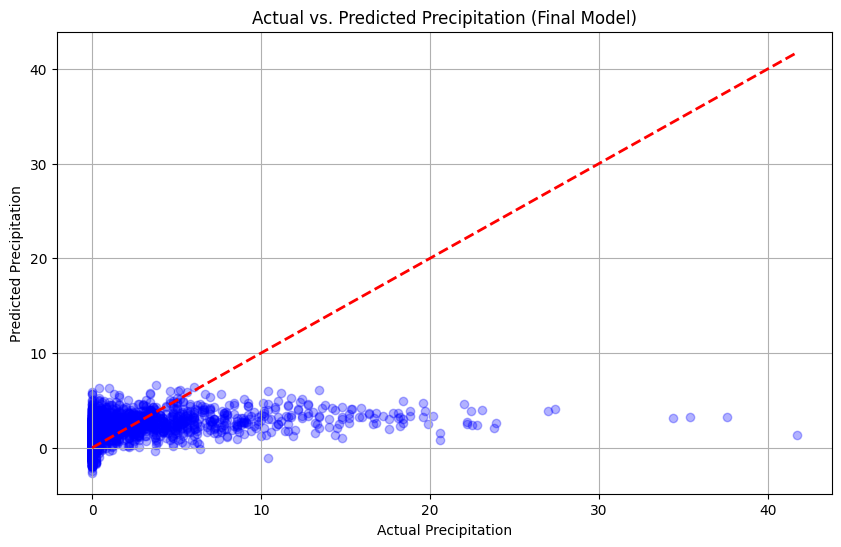

In [107]:
import matplotlib.pyplot as plt

final_model = LinearRegression()
final_model.fit(x_od1, y_od1) 
y_pred_final = final_model.predict(x_test_best)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_final, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Precipitation')
plt.ylabel('Predicted Precipitation')
plt.title('Actual vs. Predicted Precipitation (Final Model)')
plt.grid(True)
plt.show()

In [108]:
print("="*30)
print("FINAL PROJECT SUMMARY")
print("="*30)
print(f"Baseline R-squared:          {r2_baseline:.6f}")
print(f"Post-Transformation:         {best_t_r2:.6f} ({best_t_name})")
print(f"Post-Feature Selection:      {best_fs_r2:.6f}")
print(f"Post-Outlier Detection:      {best_od_r2:.6f}")
print("-" * 30)
print(f"FINAL MODEL R-SQUARED:       {best_od_r2:.6f}")
print("="*30)

FINAL PROJECT SUMMARY
Baseline R-squared:          0.162019
Post-Transformation:         0.162019 (Min-Max)
Post-Feature Selection:      0.156766
Post-Outlier Detection:      0.156766
------------------------------
FINAL MODEL R-SQUARED:       0.156766
